<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/DAY-18-Gradient_Boosting_Regressor_(Basic_Model).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GOAL
# 🚗 Car ki fuel efficiency (MPG) predict karna using Gradient Boosting Regression

# 1.🚗 Dataset — MPG

Hum Seaborn ka built-in MPG dataset use karenge.

Isme cars ke baare mein information hai:
| Feature        | Meaning             |
| -------------- | ------------------- |
| `mpg`          | Fuel efficiency     |
| `cylinders`    | Engine cylinders    |
| `displacement` | Engine displacement |
| `horsepower`   | Engine power        |
| `weight`       | Car weight          |
| `acceleration` | Acceleration        |
| `model_year`   | Car model year      |
1

🎯 Target - mpg (millage per gallon)

# 2. 📚 Libraries Import

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# 3. 📥 Dataset Load Karo

In [7]:
df= sns.load_dataset('mpg')

In [8]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [10]:
df.shape

(398, 9)

In [11]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [12]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [13]:
df=df.dropna().reset_index(drop = True)
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
388,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
389,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
390,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [14]:
df.shape

(392, 9)

In [15]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
name,0


# 5. 📊 EDA — MPG Distribution

Sabse pehle target ko samjho.

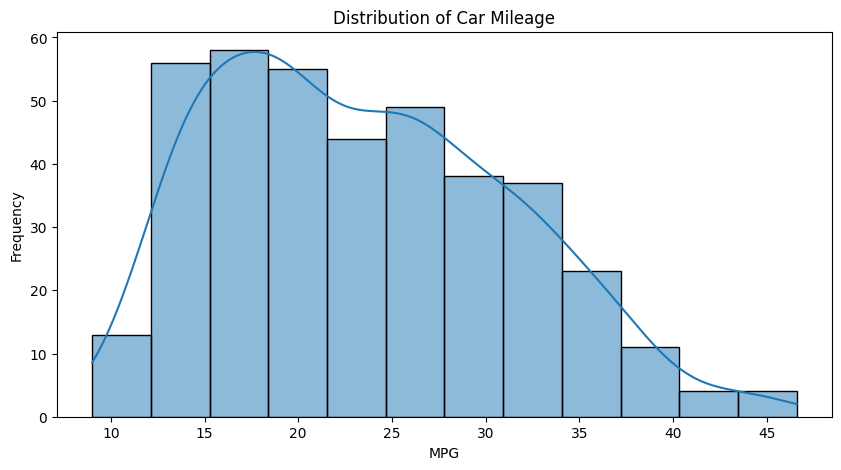

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["mpg"],
    kde=True
)

plt.title("Distribution of Car Mileage")
plt.xlabel("MPG")
plt.ylabel("Frequency")

plt.show()
# Isse pata chalega ki cars ki MPG values kis range mein distributed hain.


# 6. 🔥 Correlation Heatmap

Ab features aur MPG ke beech relationship dekhenge.

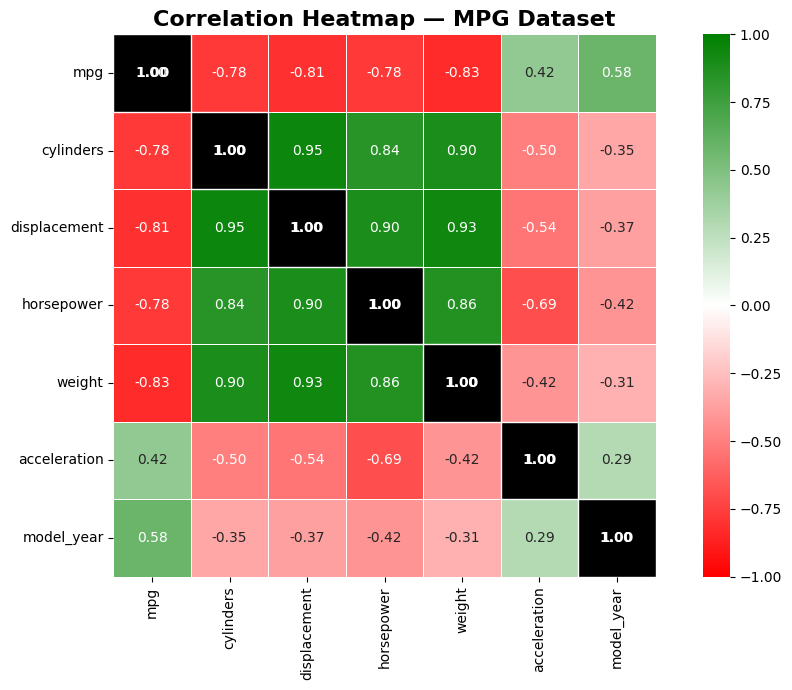

In [17]:
plt.figure(figsize=(10, 7))

corr_data = df[
    [
        "mpg",
        "cylinders",
        "displacement",
        "horsepower",
        "weight",
        "acceleration",
        "model_year"
    ]
].corr()

# Custom color map
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "custom_corr",
    [
        "red",       # Strong negative
        "white",     # Zero
        "green"      # Strong positive
    ]
)

# Heatmap
ax = sns.heatmap(
    corr_data,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True
)

# Make diagonal cells black
for i in range(len(corr_data)):
    ax.add_patch(
        plt.Rectangle(
            (i, i),
            1,
            1,
            fill=True,
            color="black",
            ec="white"
        )
    )

    # Diagonal value ko white mein show karo
    ax.text(
        i + 0.5,
        i + 0.5,
        "1.00",
        ha="center",
        va="center",
        color="white",
        fontweight="bold"
    )

plt.title(
    "Correlation Heatmap — MPG Dataset",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [18]:
# positive correlation - model year & mpg
# negative correlation - weight & mpg

# 7. 🚗 Weight vs MPG
Ek important relationship visualize karte hain:

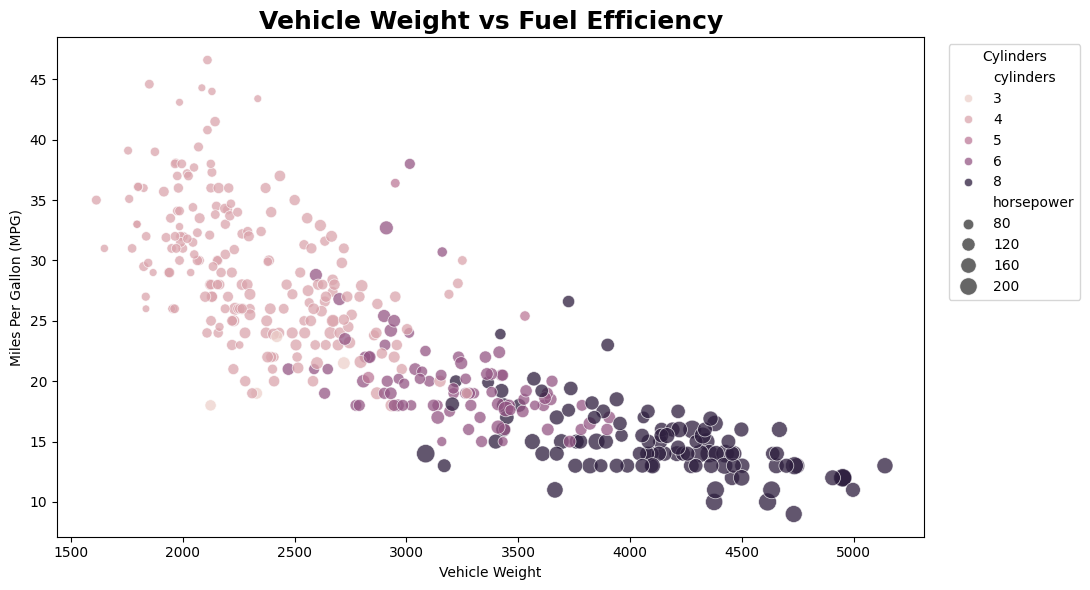

In [19]:
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg",
    hue="cylinders",
    size="horsepower",
    sizes=(30, 180),
    alpha=0.75
)

plt.title(
    "Vehicle Weight vs Fuel Efficiency",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Vehicle Weight")
plt.ylabel("Miles Per Gallon (MPG)")

plt.legend(
    title="Cylinders",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# 8. 🎯 X aur y Define Karo

Features:

In [20]:
features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
]

In [21]:
x = df[features]

In [22]:
y = df["mpg"]

In [23]:
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (392, 6)
y shape: (392,)


# 9. ✂️ Train-Test Split

In [24]:
x_train ,x_test, y_train,y_test  = train_test_split(
    x,y,
    test_size = 0.2,
    random_state = 42
)

# 10. 🚀 Gradient Boosting Regressor

Ab actual Scikit-Learn model banayenge.

In [25]:
gb = GradientBoostingRegressor(
    n_estimators = 100,
    max_depth = 2,
    learning_rate = 0.05,
    random_state = 42
)

# 11. 🏋️ Model Train Karo

In [26]:
gb.fit(x_train,y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, random_state=42)

Initial Prediction

       ↓
Residual / Negative Gradient

       ↓
Regression Tree

       ↓
Correction

       ↓
Add to Existing Model

       ↓
Next Tree

       ↓
...

# 12. 🔮 Predictions

In [27]:
y_pred = gb.predict(x_test)

In [28]:
comparison = pd.DataFrame({
    "Actual MPG": y_test.values,
    "Predicted MPG": y_pred
})

comparison.head(10)

,Actual MPG,Predicted MPG
0,26.0,27.316791
1,21.6,22.932386
2,36.1,34.936949
3,26.0,29.450882
4,27.0,27.402223
5,28.0,27.959020
6,13.0,13.239564
7,26.0,28.265056
8,19.0,18.056934
9,29.0,29.231748


# 13. ⚠️ Regression mein Accuracy Score?

In [29]:
# not used ,

# 14. 📊 Complete Model Evaluation

1. R² Score

In [30]:
# r2 - Model target ki variability ko kitna explain kar raha hai.
r2 = r2_score(y_test,y_pred)
print("R² Score:", r2)

R² Score: 0.8698463979503296


2. MAE

In [31]:
# mean absolute error - Prediction average mein kitni MPG se off hai.
mae = mean_absolute_error(y_test,y_pred)
print("MAE :" ,mae)

MAE : 1.8947751016224776


3.MSE

In [32]:
mse = mean_squared_error(y_test,y_pred)
print('MSE: ',mse)

MSE:  6.643115759384517


4. RMSE

In [33]:
# rmse = root mean square error
# Large prediction errors ko zyada punish karta hai.
rmse = np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 2.5774242490099524


# 15. 🎯 Agar Tumhe "Accuracy %" Zaroor Dikhani Hai

Technically regression ke liye accuracy_score nahi hota.

Lekin hum ek custom tolerance accuracy bana sakte hain.

Question:

Kitni predictions actual MPG se ±10% ke andar hain?

In [34]:
tolerance = 0.10

accuracy_10 = np.mean(
    np.abs(y_pred - y_test.values)
    <= tolerance * np.abs(y_test.values)
)

print(
    f"Predictions within ±10%: "
    f"{accuracy_10 * 100:.2f}%"
)

Predictions within ±10%: 69.62%


# 16. 📈 Actual vs Predicted Plot

Ye regression project ka important visualization hai.

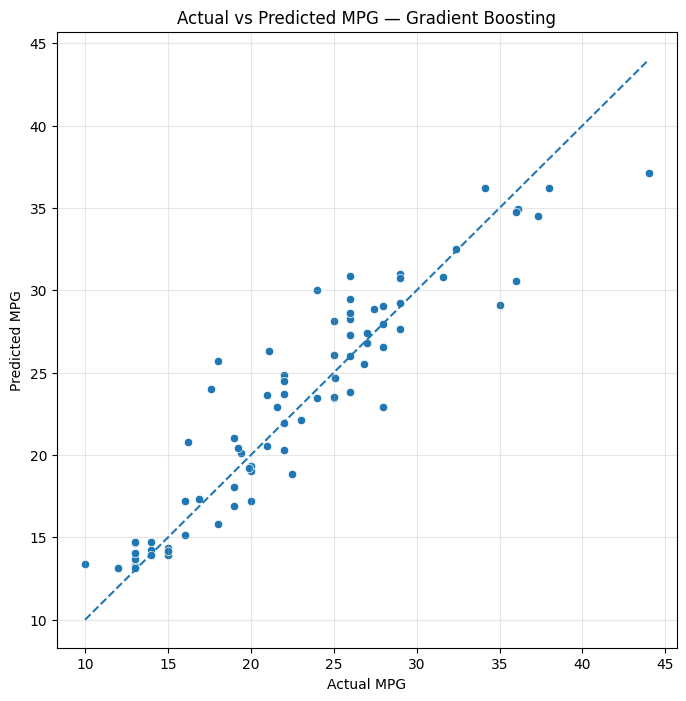

In [35]:
plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")

plt.title(
    "Actual vs Predicted MPG — Gradient Boosting"
)

plt.grid(alpha=0.3)

plt.show()

# 17. 🔥 Ab Aata Hai Additive Modeling
Ye part tumhare scratch implementation se directly connect hota hai.

In [37]:
gb.staged_predict(x_test)

<generator object GradientBoostingRegressor.staged_predict at 0x7e95ef69cfb0>

In [38]:
staged_predictions = list(
    gb.staged_predict(x_test)
)

# 18. Additive Modeling ko Samjho

Suppose:
$$ F_0(x)=20 $$

Then:

$$ F_1(x)=F_0(x)+0.05h_1(x) $$

Then:

$$ F_2(x)=F_1(x)+0.05h_2(x) $$

Then:

$$ F_3(x)=F_2(x)+0.05h_3(x) $$

Eventually:

$$ \boxed{ F_{100}(x)=F_0(x)+ 0.05h_1(x)+ 0.05h_2(x)+...+ 0.05h_{100}(x) } $$

🔥 Ye hi additive modeling hai.

* Har tree existing model ko replace nahi karta.

* Har tree existing model mein ek correction add karta hai.

# 19. 📉 Har Stage ka Error Calculate Karo

In [43]:
stage_mse = []

for stage_pred in staged_predictions:

    mse = mean_squared_error(
        y_test, stage_pred )

    stage_mse.append(mse)
stage_mse

[47.8758918460462,
 44.59894210510897,
 41.51057793049329,
 38.7353487655276,
 36.270512936446764,
 34.10162756952877,
 32.03944822987235,
 30.04163530742187,
 28.26489870747972,
 26.479528046735055,
 24.867436379388323,
 23.509710433342306,
 22.333208896573375,
 21.205644996616783,
 20.078457846475303,
 19.169923698200343,
 18.17467873052055,
 17.46412975624685,
 16.64293271212186,
 15.908947952080535,
 15.224204539774538,
 14.771480790293513,
 14.13147240999654,
 13.741775084201237,
 13.164283987110288,
 12.70052778326788,
 12.271563305391139,
 11.891830987944031,
 11.681520679789575,
 11.307554050879236,
 11.03895556073727,
 10.74172110385419,
 10.508543213374052,
 10.370417816828345,
 10.109246330374015,
 9.879016867839066,
 9.637953634548994,
 9.499409141000148,
 9.298125587997445,
 9.17382423111952,
 8.982819344670874,
 8.810187346968137,
 8.70743494751291,
 8.499488005164471,
 8.437313516078536,
 8.411348073290606,
 8.3179005220349,
 8.268465726518038,
 8.21051119370474,
 8.1633

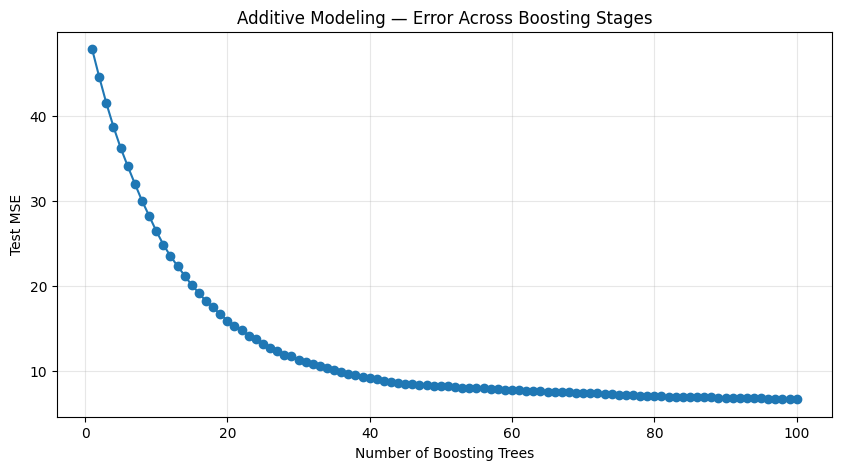

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(stage_mse) + 1),
    stage_mse,
    marker="o"
)

plt.xlabel("Number of Boosting Trees")
plt.ylabel("Test MSE")

plt.title(
    "Additive Modeling — Error Across Boosting Stages"
)

plt.grid(alpha=0.3)

plt.show()


# 20. 🔥 Different Stages ki Predictions Visualize Karo

Hum 10, 30, 60 aur 100 trees ke baad model ko dekhenge.

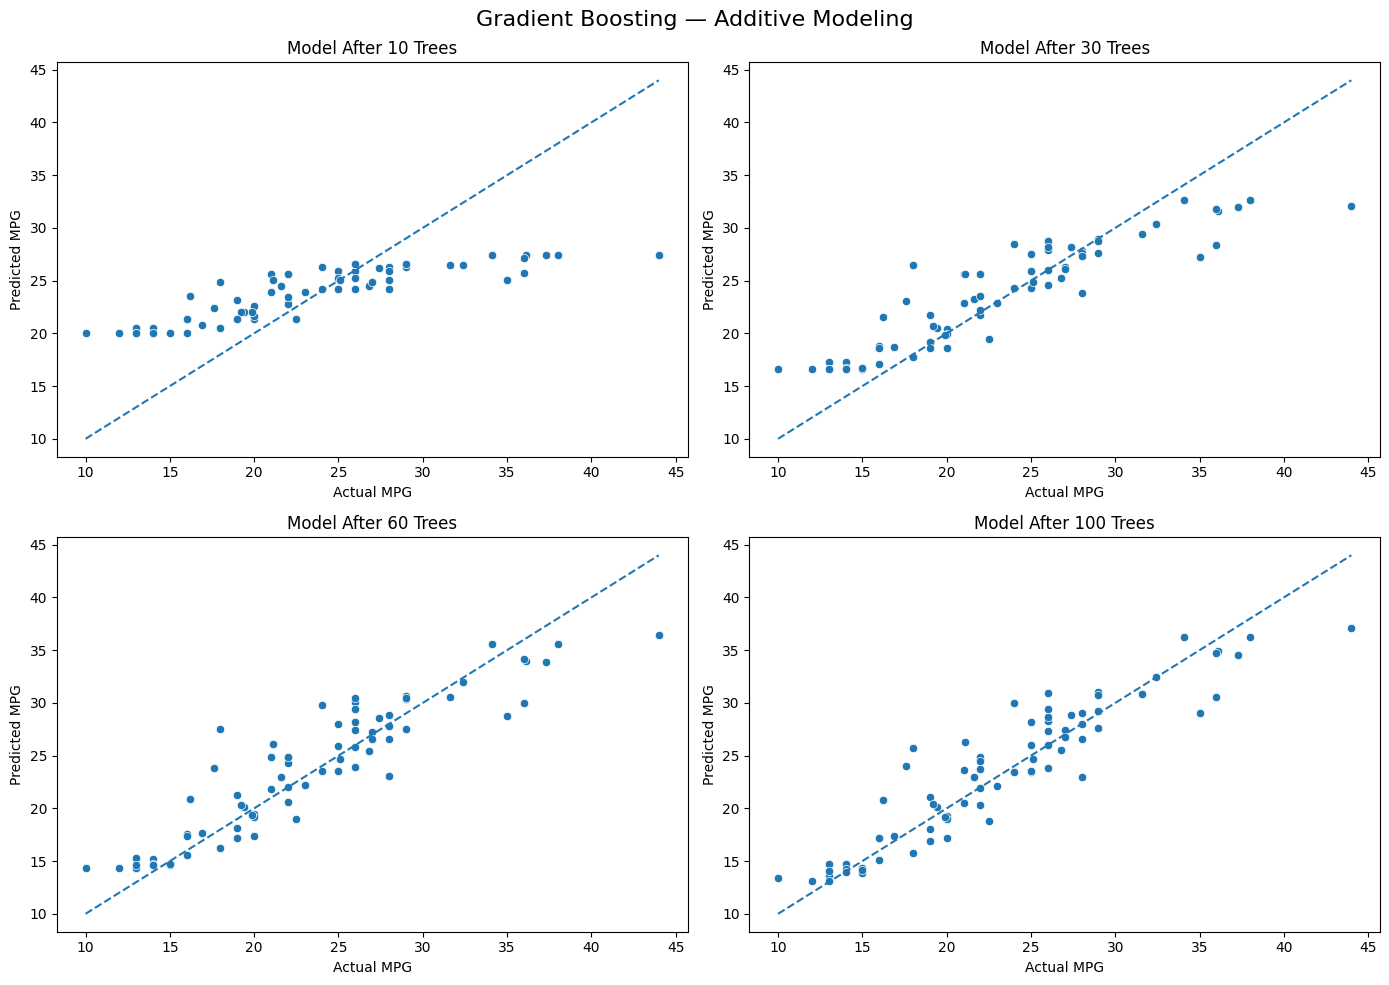

In [44]:
stages = [10, 30, 60, 100]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

axes = axes.ravel()

for ax, stage in zip(axes, stages):

    predictions = staged_predictions[stage - 1]

    sns.scatterplot(
        x=y_test,
        y=predictions,
        ax=ax
    )

    ax.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )

    ax.set_title(
        f"Model After {stage} Trees"
    )

    ax.set_xlabel("Actual MPG")
    ax.set_ylabel("Predicted MPG")

plt.suptitle(
    "Gradient Boosting — Additive Modeling",
    fontsize=16
)

plt.tight_layout()

plt.show()

# 21. 📉 Residual Analysis

Final model ke residuals:

Residual=Actual−Predicted

In [45]:
residuals = y_test - y_pred

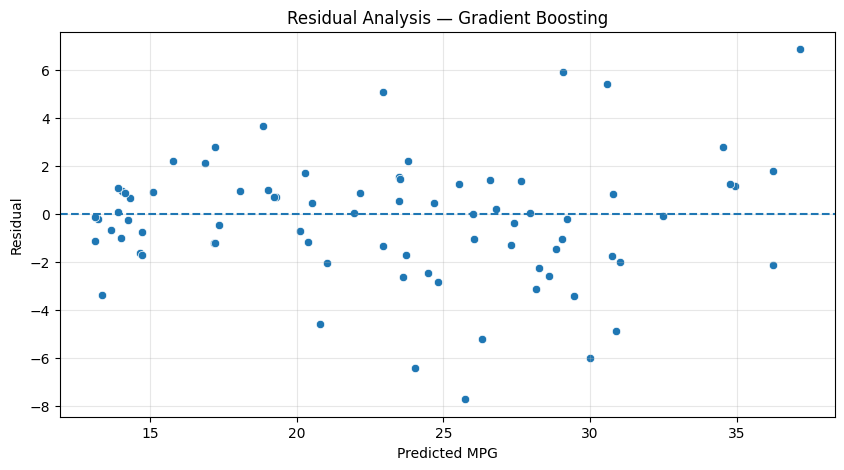

In [46]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted MPG")
plt.ylabel("Residual")

plt.title(
    "Residual Analysis — Gradient Boosting"
)

plt.grid(alpha=0.3)

plt.show()

# 22. 🌳 Feature Importance

Gradient Boosting hume bata sakta hai ki kaunse features model ke liye useful rahe.

In [48]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": gb.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance

,Feature,Importance
1,displacement,0.340009
3,weight,0.232730
2,horsepower,0.202742
5,model_year,0.146661
0,cylinders,0.073646
4,acceleration,0.004212


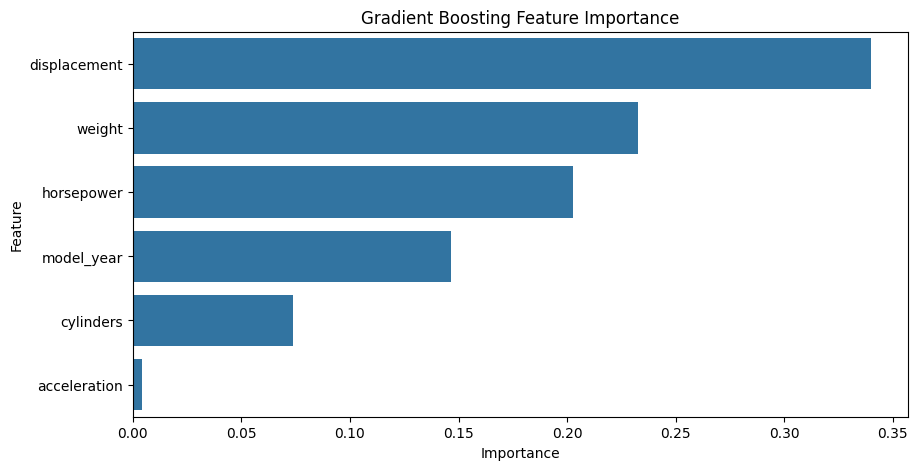

In [49]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Gradient Boosting Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# 🎯 Final Project Structure
01. Import Libraries
        ↓
02. Load MPG Dataset
        ↓
03. df.head()
        ↓
04. df.info()
        ↓
05. df.describe()
        ↓
06. Missing Values
        ↓
07. Data Cleaning
        ↓
08. MPG Distribution
        ↓
09. Correlation Heatmap
        ↓
10. Weight vs MPG
        ↓
11. X and y
        ↓
12. Train-Test Split
        ↓
13. GradientBoostingRegressor
        ↓
14. Model Training
        ↓
15. Prediction
        ↓
16. R²
17. MAE
18. RMSE
19. ±10% Custom Accuracy
        ↓
20. Actual vs Predicted
        ↓
21. Additive Modeling
        ↓
22. Stage-wise MSE
        ↓
23. Stage-wise Predictions
        ↓
24. Residual Analysis
        ↓
25. Feature Importance